## Summary

**11 raw features** extracted per subject (3 onset, 4 encounter, 4 terminal).

**4 a priori vigor dimensions:**
1. **Tonic Vigor** = z-mean of (onset_mean_mean, enc_baseline, term_baseline)
2. **Anticipatory Mobilization** = z-mean of (onset_slope_mean, onset_threat_mod)
3. **Reactive Spike** = z-scored enc_selective_spike
4. **Terminal Persistence** = z-mean of (term_attack_boost, term_attack_slope)

**Choice parameters** (z, κ, β) merged from hierarchical Bayesian model fits.

Output: `subject_vigor_table.csv` (292 rows) ready for NB3 (choice-vigor mapping) and NB4 (clinical prediction).

In [13]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import zscore, pearsonr
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──
DATA_PROC = Path('../../data/processed')
DATA_RAW  = Path('../../data/raw')
RESULTS   = Path('../../results')
FIG_DIR   = Path('../../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

DPI = 150
plt.style.use('seaborn-v0_8-whitegrid')

# ── Load trial-level metrics from NB1 ──
df = pd.read_parquet(DATA_PROC / 'phase_trial_metrics.parquet')
print(f'Trial metrics: {df.shape[0]:,} trials, {df["subj"].nunique()} subjects')

# ── Load phase time series from NB1 ──
encounter_ts = pd.read_parquet(DATA_PROC / 'encounter_phase_ts.parquet')
terminal_ts  = pd.read_parquet(DATA_PROC / 'terminal_phase_ts.parquet')
print(f'Encounter TS: {len(encounter_ts):,} rows')
print(f'Terminal TS:  {len(terminal_ts):,} rows')

Trial metrics: 13,140 trials, 292 subjects
Encounter TS: 532,168 rows
Terminal TS:  525,625 rows


In [14]:
# ── LOAD CHOICE MODEL PARAMETERS ─────────────────────────────────────────────

mapping = pd.read_csv(DATA_RAW / 'subject_mapping.csv')
z_params = pd.read_csv(RESULTS / 'FET_Exp_Bias_z_params.csv')
k_params = pd.read_csv(RESULTS / 'FET_Exp_Bias_k_params.csv')
beta_params = pd.read_csv(RESULTS / 'FET_Exp_Bias_beta_params.csv')

# Build parameter table
param_df = mapping.copy()
param_df = param_df.merge(
    z_params[['subject', 'mean']].rename(columns={'subject': 'subj', 'mean': 'z'}),
    on='subj')
param_df = param_df.merge(
    k_params[['subject', 'mean']].rename(columns={'subject': 'subj', 'mean': 'kappa'}),
    on='subj')
param_df = param_df.merge(
    beta_params[['subject', 'mean']].rename(columns={'subject': 'subj', 'mean': 'beta'}),
    on='subj')

# Exclude subject 197
param_df = param_df[param_df['subj'] != 197].copy()

# Z-score parameters
for p in ['z', 'kappa', 'beta']:
    param_df[f'{p}_z'] = (param_df[p] - param_df[p].mean()) / param_df[p].std()

print(f'Parameters loaded for {len(param_df)} subjects')
print(param_df[['z', 'kappa', 'beta']].describe().round(3))

Parameters loaded for 292 subjects
             z    kappa     beta
count  292.000  292.000  292.000
mean     0.377    1.950    1.440
std      0.221    1.257    1.897
min      0.140    0.330    0.197
25%      0.238    0.964    0.479
50%      0.313    1.501    0.860
75%      0.427    2.678    1.643
max      1.458    4.757   13.675


## Section 1: Per-Subject Feature Extraction

### 1A. Onset Features

From trial-level DVs, compute per-subject:
- `onset_slope_mean` — average ramp rate
- `onset_mean_mean` — average vigor level in onset window
- `onset_threat_mod` — within-subject slope of onset_slope on threat (threat modulation of ramp)

In [15]:
# ── 1A: ONSET FEATURES ────────────────────────────────────────────────────────

# Per-subject means
subj_onset = df.groupby('subj').agg(
    onset_slope_mean=('onset_slope', 'mean'),
    onset_mean_mean=('onset_mean', 'mean'),
).reset_index()

# Threat modulation: within-subject OLS slope of onset_slope on threat_c
def _threat_mod(grp):
    vals = grp.dropna(subset=['onset_slope'])
    if len(vals) < 10:
        return np.nan
    return np.polyfit(vals['threat_c'], vals['onset_slope'], 1)[0]

onset_tmod = df.groupby('subj').apply(_threat_mod, include_groups=False)
subj_onset = subj_onset.merge(
    onset_tmod.rename('onset_threat_mod').reset_index(),
    on='subj')

print('Onset features:')
print(subj_onset.describe().round(4))

Onset features:
           subj  onset_slope_mean  onset_mean_mean  onset_threat_mod
count  292.0000          292.0000         292.0000          292.0000
mean   146.8288            0.0000           0.0000            0.0347
std     84.8207            0.2144           0.2566            0.1389
min      1.0000           -0.3266          -0.3052           -0.3951
25%     73.7500           -0.1843          -0.2266           -0.0359
50%    146.5000           -0.0295          -0.0462            0.0240
75%    220.2500            0.1639           0.1760            0.1071
max    293.0000            0.6321           0.8287            1.1281


### 1B. Encounter Features

For each subject, fit `vigor_resid ~ post * attack` to their pooled encounter time series.

This yields:
- `enc_baseline` — pre-event vigor on non-attack trials (Intercept)
- `enc_post_effect` — time-locked change, non-attack (manipulation check, should ≈ 0)
- `enc_attack_effect` — pre-encounter attack difference (manipulation check, should ≈ 0)
- `enc_selective_spike` — **attack × post interaction = selective encounter reactivity**

In [16]:
# ── 1B: ENCOUNTER FEATURES ────────────────────────────────────────────────────

def _encounter_subj_features(subj_data):
    """Fit post × attack model to one subject's encounter time series."""
    d = subj_data.copy()
    d['post'] = d['post'].astype(float)
    d['attack'] = d['attack'].astype(float)
    try:
        fit = smf.ols('vigor_resid ~ post * attack', data=d).fit()
        return pd.Series({
            'enc_baseline':        fit.params['Intercept'],
            'enc_post_effect':     fit.params['post'],
            'enc_attack_effect':   fit.params['attack'],
            'enc_selective_spike':  fit.params['post:attack'],
        })
    except Exception as e:
        return pd.Series({
            'enc_baseline': np.nan, 'enc_post_effect': np.nan,
            'enc_attack_effect': np.nan, 'enc_selective_spike': np.nan,
        })

print('Fitting encounter models per subject...')
subj_enc = (encounter_ts.groupby('subj')
    .apply(_encounter_subj_features, include_groups=False)
    .reset_index())

print(f'Encounter features: {subj_enc.shape}')
print(subj_enc.describe().round(4))

# ── Manipulation checks ──
from scipy.stats import ttest_1samp
for col, label in [('enc_post_effect', 'Post effect (should ≈ 0)'),
                    ('enc_attack_effect', 'Attack effect (should ≈ 0)')]:
    vals = subj_enc[col].dropna()
    t, p = ttest_1samp(vals, 0)
    print(f'  {label}: M={vals.mean():.4f}, t={t:.2f}, p={p:.4f}')

Fitting encounter models per subject...
Encounter features: (292, 5)
           subj  enc_baseline  enc_post_effect  enc_attack_effect  \
count  292.0000      292.0000         292.0000           292.0000   
mean   146.8288       -0.0071          -0.0087             0.0239   
std     84.8207        0.2755           0.1612             0.0909   
min      1.0000       -0.6498          -0.3387            -0.3574   
25%     73.7500       -0.1816          -0.1347            -0.0220   
50%    146.5000        0.0146          -0.0372             0.0288   
75%    220.2500        0.1969           0.1055             0.0767   
max    293.0000        0.6914           0.5639             0.3467   

       enc_selective_spike  
count             292.0000  
mean                0.0161  
std                 0.0858  
min                -0.2700  
25%                -0.0401  
50%                 0.0046  
75%                 0.0701  
max                 0.2740  
  Post effect (should ≈ 0): M=-0.0087, t=-0.92, 

### 1C. Terminal Features

For each subject, fit `vigor_resid ~ t_term * attack` to their pooled terminal time series.

This yields:
- `term_baseline` — terminal vigor on non-attack trials (Intercept)
- `term_slope_base` — persistence on non-attack trials
- `term_attack_boost` — **threat-driven vigor increase**
- `term_attack_slope` — threat-driven persistence change

In [17]:
# ── 1C: TERMINAL FEATURES ─────────────────────────────────────────────────────

def _terminal_subj_features(subj_data):
    """Fit t_term × attack model to one subject's terminal time series."""
    d = subj_data.copy()
    d['attack'] = d['attack'].astype(float)
    try:
        fit = smf.ols('vigor_resid ~ t_term * attack', data=d).fit()
        return pd.Series({
            'term_baseline':     fit.params['Intercept'],
            'term_slope_base':   fit.params['t_term'],
            'term_attack_boost': fit.params['attack'],
            'term_attack_slope': fit.params['t_term:attack'],
        })
    except Exception as e:
        return pd.Series({
            'term_baseline': np.nan, 'term_slope_base': np.nan,
            'term_attack_boost': np.nan, 'term_attack_slope': np.nan,
        })

print('Fitting terminal models per subject...')
subj_term = (terminal_ts.groupby('subj')
    .apply(_terminal_subj_features, include_groups=False)
    .reset_index())

print(f'Terminal features: {subj_term.shape}')
print(subj_term.describe().round(4))

Fitting terminal models per subject...
Terminal features: (292, 5)
           subj  term_baseline  term_slope_base  term_attack_boost  \
count  292.0000       292.0000         292.0000           292.0000   
mean   146.8288         0.3022           0.0390            -0.1581   
std     84.8207         0.2506           0.0652             0.1701   
min      1.0000        -0.2091          -0.1361            -1.0355   
25%     73.7500         0.1821          -0.0051            -0.2455   
50%    146.5000         0.2902           0.0408            -0.1369   
75%    220.2500         0.4123           0.0772            -0.0461   
max    293.0000         2.2986           0.3638             0.2374   

       term_attack_slope  
count           292.0000  
mean             -0.0021  
std               0.0889  
min              -0.2892  
25%              -0.0527  
50%              -0.0098  
75%               0.0306  
max               0.7382  


In [18]:
# ── 1D: ASSEMBLE RAW FEATURE TABLE ────────────────────────────────────────────

subj_features = (subj_onset
    .merge(subj_enc, on='subj')
    .merge(subj_term, on='subj'))

print(f'Raw feature table: {subj_features.shape}')
print(f'Subjects with complete data: '
      f'{subj_features.dropna().shape[0]} / {len(subj_features)}')

# Show all features
feature_cols = [c for c in subj_features.columns if c != 'subj']
print(f'\n{len(feature_cols)} features: {feature_cols}')

Raw feature table: (292, 12)
Subjects with complete data: 292 / 292

11 features: ['onset_slope_mean', 'onset_mean_mean', 'onset_threat_mod', 'enc_baseline', 'enc_post_effect', 'enc_attack_effect', 'enc_selective_spike', 'term_baseline', 'term_slope_base', 'term_attack_boost', 'term_attack_slope']


## Section 2: Four A Priori Vigor Dimensions

**No PCA. No data-driven reduction. Theory-driven composites only.**

The original three-composite structure (tonic, threat reactivity, phasic burst)
collapsed anticipatory and reactive threat responses into a single dimension.
This destroys the z crossover — hazard sensitivity (z) *increases* anticipatory
mobilization but *decreases* reactive spike. These are opposite poles of the
tonic-phasic tradeoff and must be kept separate.

| Dimension | Components | Interpretation |
|-----------|-----------|----------------|
| Tonic Vigor | onset_mean_mean, enc_baseline, term_baseline | Global effort regardless of threat |
| Anticipatory Mobilization | onset_slope_mean, onset_threat_mod | Pre-encounter ramp-up and its threat sensitivity |
| Reactive Spike | enc_selective_spike | Selective encounter reactivity (attack × post) |
| Terminal Persistence | term_attack_boost, term_attack_slope | Threat-driven effort during escape/capture |

In [19]:
# ── DIMENSION 1: TONIC VIGOR ──────────────────────────────────────────────────
# "How much do they press regardless of threat?"
# Average of baseline vigor across all three phases (z-scored first)

tonic_components = ['onset_mean_mean', 'enc_baseline', 'term_baseline']

for col in tonic_components:
    subj_features[f'{col}_z'] = zscore(subj_features[col], nan_policy='omit')

subj_features['tonic_vigor'] = subj_features[
    [f'{c}_z' for c in tonic_components]
].mean(axis=1)

# ── DIMENSION 2: ANTICIPATORY MOBILIZATION ────────────────────────────────────
# "How much do they ramp up before encounter, and does threat amplify it?"
# Combines onset ramp rate and its threat modulation

antic_components = ['onset_slope_mean', 'onset_threat_mod']

for col in antic_components:
    subj_features[f'{col}_z'] = zscore(subj_features[col], nan_policy='omit')

subj_features['anticipatory_mobilization'] = subj_features[
    [f'{c}_z' for c in antic_components]
].mean(axis=1)

# ── DIMENSION 3: REACTIVE SPIKE ────────────────────────────────────────────────
# "How much does encounter selectively boost their vigor?"
# Directly the enc_selective_spike (attack × post interaction), z-scored

subj_features['reactive_spike'] = zscore(
    subj_features['enc_selective_spike'], nan_policy='omit')

# ── DIMENSION 4: TERMINAL PERSISTENCE ─────────────────────────────────────────
# "How much does active threat change their terminal effort?"
# Combines attack boost on terminal level and slope

term_components = ['term_attack_boost', 'term_attack_slope']

for col in term_components:
    subj_features[f'{col}_z'] = zscore(subj_features[col], nan_policy='omit')

subj_features['terminal_persistence'] = subj_features[
    [f'{c}_z' for c in term_components]
].mean(axis=1)

# ── Report ──
dims = ['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike', 'terminal_persistence']
print('Vigor dimensions computed:')
for dim in dims:
    vals = subj_features[dim].dropna()
    print(f'  {dim:30s}: M={vals.mean():.3f}, SD={vals.std():.3f}, N={len(vals)}')

Vigor dimensions computed:
  tonic_vigor                   : M=0.000, SD=0.576, N=292
  anticipatory_mobilization     : M=0.000, SD=0.747, N=292
  reactive_spike                : M=-0.000, SD=1.002, N=292
  terminal_persistence          : M=-0.000, SD=0.720, N=292


In [20]:
# ── MERGE CHOICE PARAMETERS ───────────────────────────────────────────────────

subj_table = subj_features.merge(
    param_df[['subj', 'z', 'kappa', 'beta', 'z_z', 'kappa_z', 'beta_z']],
    on='subj', how='left')

print(f'Subject table: {subj_table.shape}')
n_complete = subj_table[['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike',
                          'terminal_persistence', 'z_z', 'kappa_z', 'beta_z']].dropna().shape[0]
print(f'Complete cases (all 4 dims + all 3 params): {n_complete}')

Subject table: (292, 29)
Complete cases (all 4 dims + all 3 params): 292


## Section 3: Quality Checks

### 3A. Split-Half Reliability

In [21]:
# ── 3A: SPLIT-HALF RELIABILITY ────────────────────────────────────────────────
# Randomly split each subject's trials into two halves (stratified by threat × attack),
# re-extract onset features on each half, compute Pearson r.

N_SPLITS = 50  # Monte Carlo iterations

def _split_half_onset(df_trials, n_splits=N_SPLITS):
    """Split-half reliability for onset features."""
    rs = {col: [] for col in ['onset_slope_mean', 'onset_mean_mean', 'onset_threat_mod']}

    for seed in range(n_splits):
        rng = np.random.RandomState(seed)
        half1_idx, half2_idx = [], []

        # Stratified split within each subject
        for subj, grp in df_trials.groupby('subj'):
            for (th, atk), cell in grp.groupby(['threat', 'attack']):
                idx = cell.index.values
                rng.shuffle(idx)
                mid = len(idx) // 2
                half1_idx.extend(idx[:mid])
                half2_idx.extend(idx[mid:])

        for half_idx, label in [(half1_idx, 'h1'), (half2_idx, 'h2')]:
            h = df_trials.loc[half_idx]
            # onset_slope_mean and onset_mean_mean
            subj_agg = h.groupby('subj').agg(
                onset_slope_mean=('onset_slope', 'mean'),
                onset_mean_mean=('onset_mean', 'mean')).reset_index()
            # onset_threat_mod
            def _tm(g):
                v = g.dropna(subset=['onset_slope'])
                if len(v) < 5: return np.nan
                return np.polyfit(v['threat_c'], v['onset_slope'], 1)[0]
            subj_agg['onset_threat_mod'] = (
                h.groupby('subj').apply(_tm, include_groups=False).values)

            if label == 'h1':
                h1_feats = subj_agg.set_index('subj')
            else:
                h2_feats = subj_agg.set_index('subj')

        # Correlate
        common = h1_feats.index.intersection(h2_feats.index)
        for col in rs:
            r = h1_feats.loc[common, col].corr(h2_feats.loc[common, col])
            rs[col].append(r)

    return {col: np.nanmean(vals) for col, vals in rs.items()}

print('Computing split-half reliability (onset features)...')
onset_reliability = _split_half_onset(df)
print('\nOnset split-half reliability (mean r across splits):')
for feat, r in onset_reliability.items():
    flag = ' ⚠️ LOW' if r < 0.3 else ''
    print(f'  {feat:25s}: r = {r:.3f}{flag}')

Computing split-half reliability (onset features)...

Onset split-half reliability (mean r across splits):
  onset_slope_mean         : r = 0.956
  onset_mean_mean          : r = 0.985
  onset_threat_mod         : r = 0.308


### 3B. Feature Intercorrelation Matrix

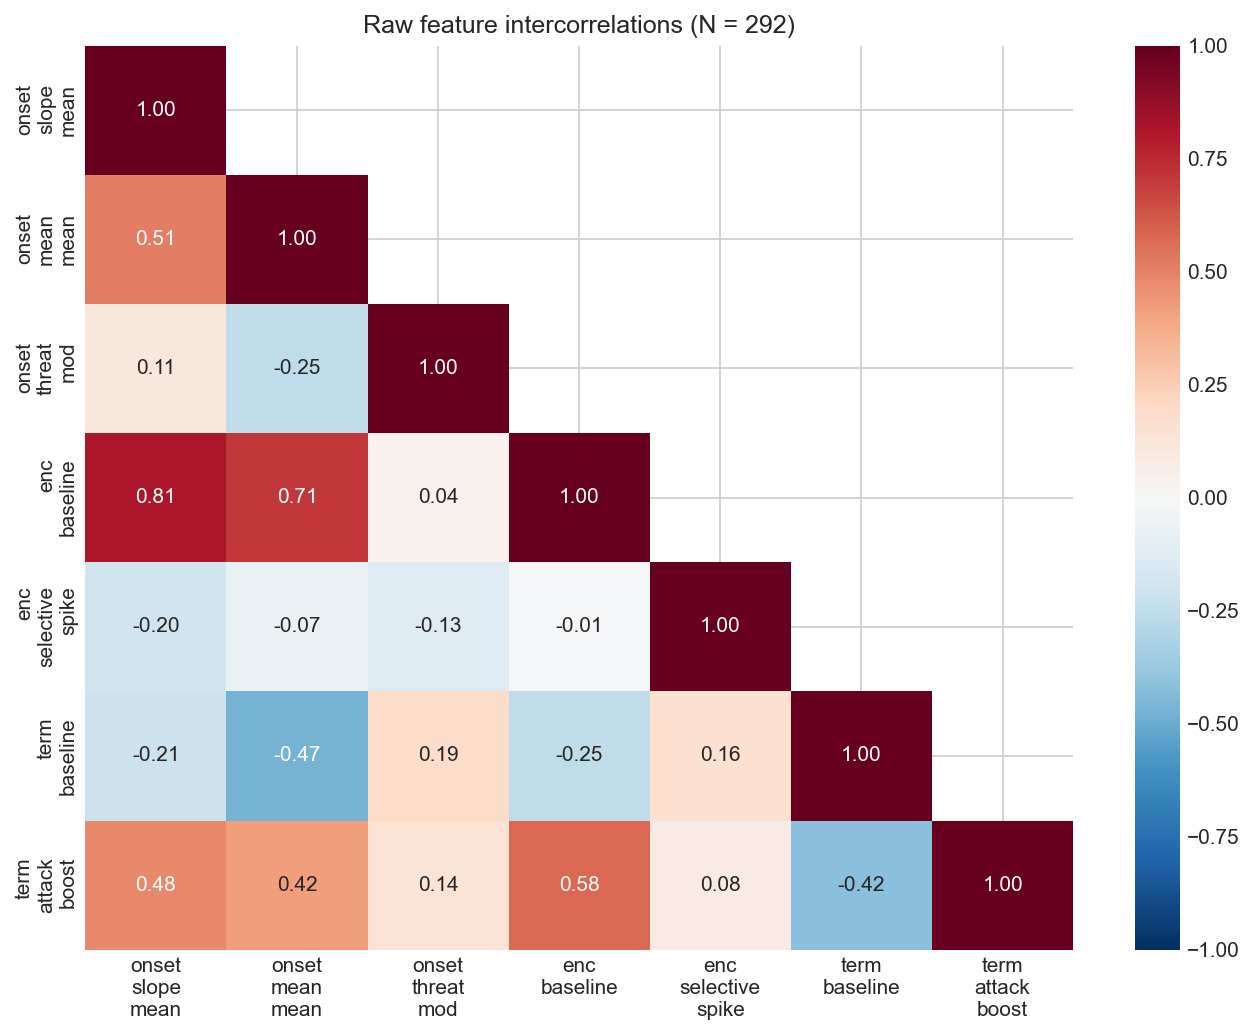


Redundancy check (|r| > 0.8):
  ⚠️  onset_slope_mean × enc_baseline: r = 0.815

Tonic-phasic tradeoff (enc_baseline × enc_selective_spike): r = -0.009
  (Expected: negative)


In [22]:
# ── 3B: INTERCORRELATION MATRIX ───────────────────────────────────────────────

# Core features (excluding manipulation checks and secondary slopes)
core_features = [
    'onset_slope_mean', 'onset_mean_mean', 'onset_threat_mod',
    'enc_baseline', 'enc_selective_spike',
    'term_baseline', 'term_attack_boost',
]

corr = subj_features[core_features].corr()

fig, ax = plt.subplots(figsize=(9, 7), dpi=DPI)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace('_', '\n') for c in core_features],
            yticklabels=[c.replace('_', '\n') for c in core_features])
ax.set_title('Raw feature intercorrelations (N = 292)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_feature_corr.png', dpi=300, bbox_inches='tight')
plt.show()

# Check for high redundancy
print('\nRedundancy check (|r| > 0.8):')
for i in range(len(core_features)):
    for j in range(i+1, len(core_features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  ⚠️  {core_features[i]} × {core_features[j]}: r = {r:.3f}')

# Check tonic-phasic tradeoff
r_tp = corr.loc['enc_baseline', 'enc_selective_spike']
print(f'\nTonic-phasic tradeoff (enc_baseline × enc_selective_spike): r = {r_tp:.3f}')
print(f'  (Expected: negative)')

### 3C. Composite Dimension Properties

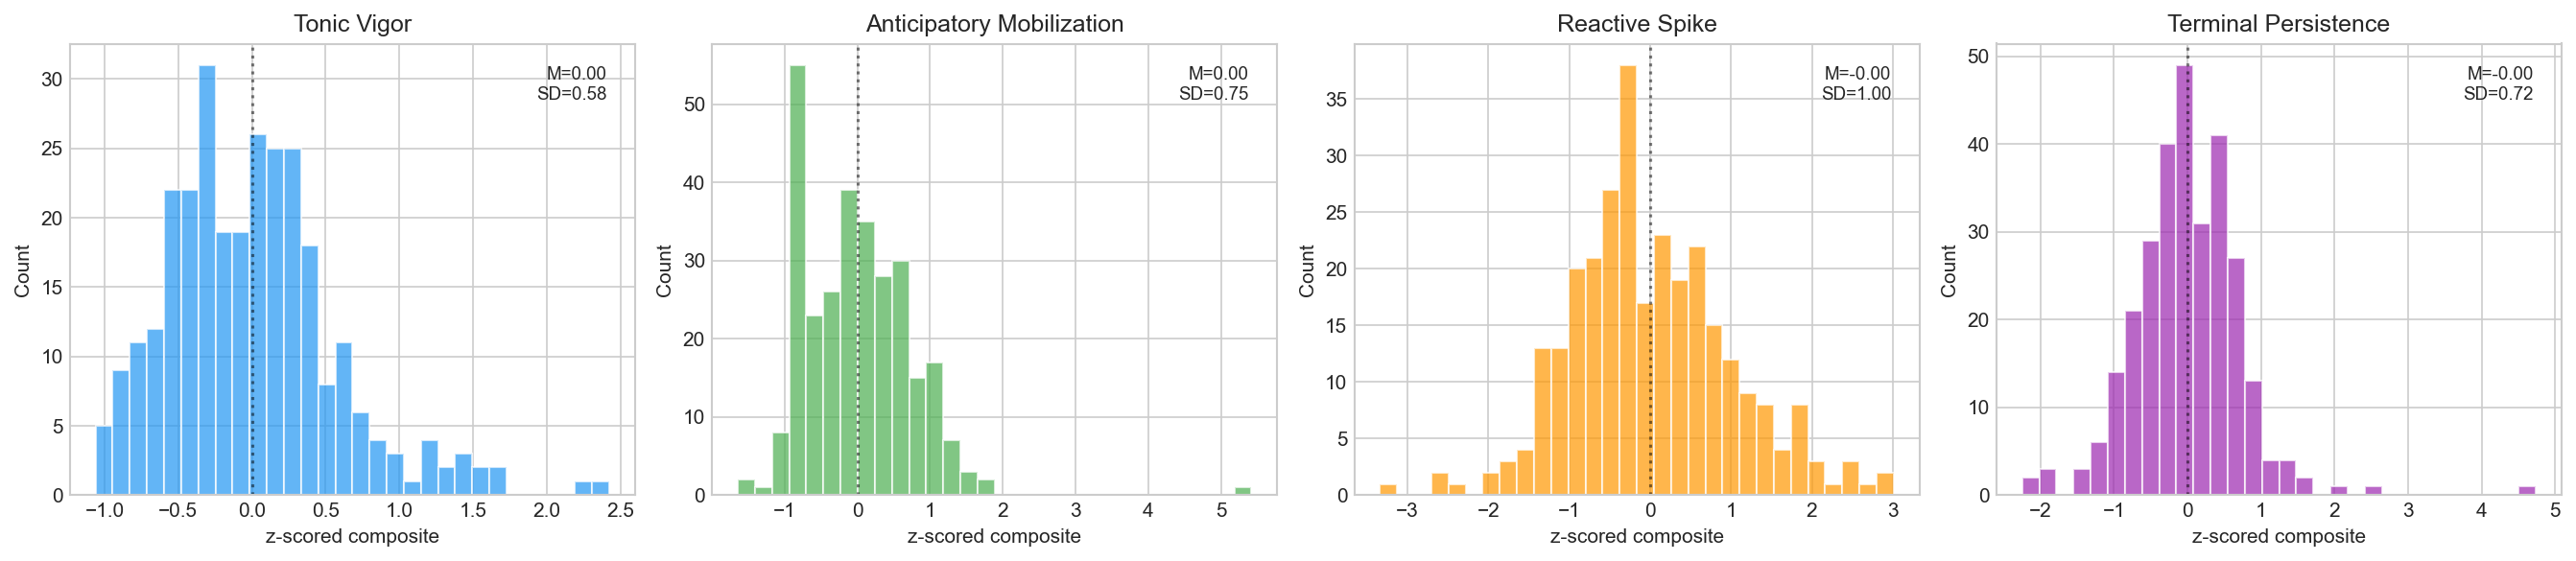

Composite intercorrelations:
                           tonic_vigor  anticipatory_mobilization  \
tonic_vigor                      1.000                      0.424   
anticipatory_mobilization        0.424                      1.000   
reactive_spike                   0.050                     -0.220   
terminal_persistence             0.178                      0.223   

                           reactive_spike  terminal_persistence  
tonic_vigor                         0.050                 0.178  
anticipatory_mobilization          -0.220                 0.223  
reactive_spike                      1.000                 0.082  
terminal_persistence                0.082                 1.000  

(Should be modest — they measure different things)

Outliers (> 3 SD):
  tonic_vigor: 2 subjects
  anticipatory_mobilization: 1 subjects
  reactive_spike: 2 subjects
  terminal_persistence: 4 subjects


In [23]:
# ── 3C: COMPOSITE DIMENSION PROPERTIES ────────────────────────────────────────

dims = ['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike', 'terminal_persistence']

# Histograms
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=DPI)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, dim, color in zip(axes, dims, colors):
    vals = subj_table[dim].dropna()
    ax.hist(vals, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='k', linestyle=':', alpha=0.5)
    ax.set_title(dim.replace('_', ' ').title())
    ax.set_xlabel('z-scored composite')
    ax.set_ylabel('Count')
    ax.text(0.95, 0.95, f'M={vals.mean():.2f}\nSD={vals.std():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_dimension_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# Intercorrelation of composites
dim_corr = subj_table[dims].corr()
print('Composite intercorrelations:')
print(dim_corr.round(3))
print('\n(Should be modest — they measure different things)')

# Outlier check
print('\nOutliers (> 3 SD):')
for dim in dims:
    vals = subj_table[dim]
    n_out = ((vals - vals.mean()).abs() > 3 * vals.std()).sum()
    print(f'  {dim}: {n_out} subjects')

## Section 4: Vigor Dimension Visualization

Demonstrate that the extracted dimensions correspond to real, visible differences
in how people execute effort across the task. For each dimension, stratify subjects
by tertile and plot the actual vigor time series — showing that these summary
statistics capture meaningful variation in the raw behavioral data.

In [25]:
# ── Load full smoothed vigor for onset phase plots ────────────────────────────
# encounter_ts and terminal_ts already loaded; need full ts for onset window.

sv = pd.read_parquet(DATA_PROC / 'smoothed_vigor_ts.parquet')
print(f'Loaded smoothed vigor: {len(sv):,} rows, cols: {list(sv.columns)}')

# Compute tertiles for each dimension
dims = ['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike', 'terminal_persistence']
dim_colors = {'Low': '#2196F3', 'Mid': '#999999', 'High': '#F44336'}

for dim in dims:
    subj_table[f'{dim}_tert'] = pd.qcut(
        subj_table[dim], 3, labels=['Low', 'Mid', 'High'])

# Merge tertiles onto each time series
tert_cols = ['subj'] + [f'{d}_tert' for d in dims]
sv_plot = sv.merge(subj_table[tert_cols], on='subj', how='left')
enc_plot = encounter_ts.merge(subj_table[tert_cols], on='subj', how='left')
term_plot = terminal_ts.merge(subj_table[tert_cols], on='subj', how='left')

# Also merge trial-level threat/attack info onto sv for onset plots
# sv already has trial-level columns from NB1; check what's available
print(f'sv columns: {sorted(sv_plot.columns)}')
print('Tertiles merged.')

Loaded smoothed vigor: 2,825,102 rows, cols: ['participantID', 'subj', 'trialName', 'trial', 't', 'r_hat', 'vigor_norm', 'vigor_resid', 'threat', 'choice', 'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime', 'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H']
sv columns: ['anticipatory_mobilization_tert', 'choice', 'distance_H', 'effort_H', 'encounterTime', 'isAttackTrial', 'outcome', 'participantID', 'r_hat', 'reactive_spike_tert', 'startDistance', 'subj', 't', 'terminal_persistence_tert', 'threat', 'tonic_vigor_tert', 'trial', 'trialCaptureTime', 'trialEndTime', 'trialEscapeTime', 'trialName', 'vigor_norm', 'vigor_resid']
Tertiles merged.


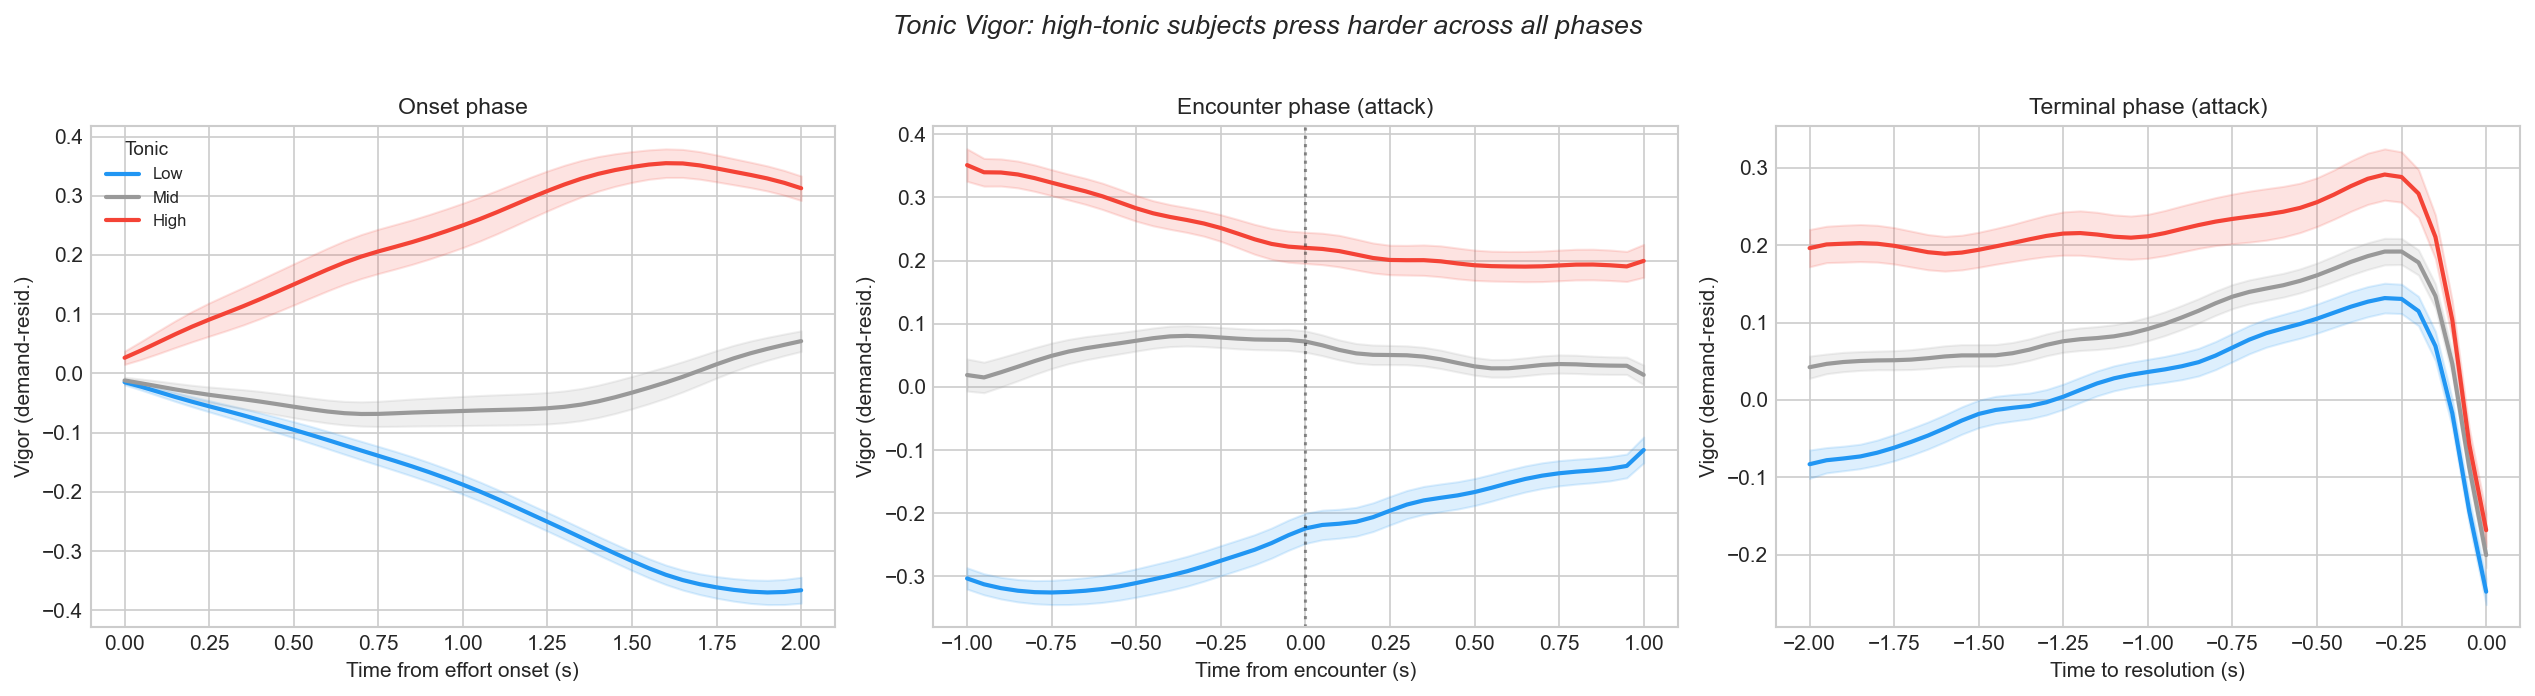

In [26]:
# ── FIGURE: Tonic Vigor — Global effort level across all task phases ──────────
# High-tonic subjects press harder everywhere; low-tonic subjects are sluggish
# throughout. This should be a level shift, not a shape change.

DT = 0.05  # 50ms bins

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), dpi=DPI)

# Panel A: Onset (0–2s from effort start)
ax = axes[0]
onset_sv = sv_plot[(sv_plot['t'] >= 0) & (sv_plot['t'] <= 2.0)].copy()
onset_sv['t_bin'] = np.round(onset_sv['t'] / DT) * DT
for tert in ['Low', 'Mid', 'High']:
    d = onset_sv[onset_sv['tonic_vigor_tert'] == tert]
    sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
    gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
    ax.plot(gm['t_bin'], gm['mean'], color=dim_colors[tert], label=tert, lw=2)
    ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                    alpha=0.15, color=dim_colors[tert])
ax.set_xlabel('Time from effort onset (s)')
ax.set_ylabel('Vigor (demand-resid.)')
ax.set_title('Onset phase', fontsize=11)
ax.legend(title='Tonic', fontsize=8, title_fontsize=9)

# Panel B: Encounter (attack trials, ±1s)
ax = axes[1]
enc_atk = enc_plot[enc_plot['attack'] == 1].copy()
enc_atk['t_bin'] = np.round(enc_atk['t_enc'] / DT) * DT
for tert in ['Low', 'Mid', 'High']:
    d = enc_atk[enc_atk['tonic_vigor_tert'] == tert]
    sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
    gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
    ax.plot(gm['t_bin'], gm['mean'], color=dim_colors[tert], label=tert, lw=2)
    ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                    alpha=0.15, color=dim_colors[tert])
ax.axvline(0, color='k', ls=':', alpha=0.4)
ax.set_xlabel('Time from encounter (s)')
ax.set_ylabel('Vigor (demand-resid.)')
ax.set_title('Encounter phase (attack)', fontsize=11)

# Panel C: Terminal (attack trials, last 2s)
ax = axes[2]
term_atk = term_plot[term_plot['attack'] == 1].copy()
term_atk['t_bin'] = np.round(term_atk['t_term'] / DT) * DT
for tert in ['Low', 'Mid', 'High']:
    d = term_atk[term_atk['tonic_vigor_tert'] == tert]
    sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
    gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
    ax.plot(gm['t_bin'], gm['mean'], color=dim_colors[tert], label=tert, lw=2)
    ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                    alpha=0.15, color=dim_colors[tert])
ax.set_xlabel('Time to resolution (s)')
ax.set_ylabel('Vigor (demand-resid.)')
ax.set_title('Terminal phase (attack)', fontsize=11)

fig.suptitle('Tonic Vigor: high-tonic subjects press harder across all phases',
             fontsize=13, y=1.02, fontstyle='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_tonic_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

Threat column: threat, values: [0.1, 0.5, 0.9]


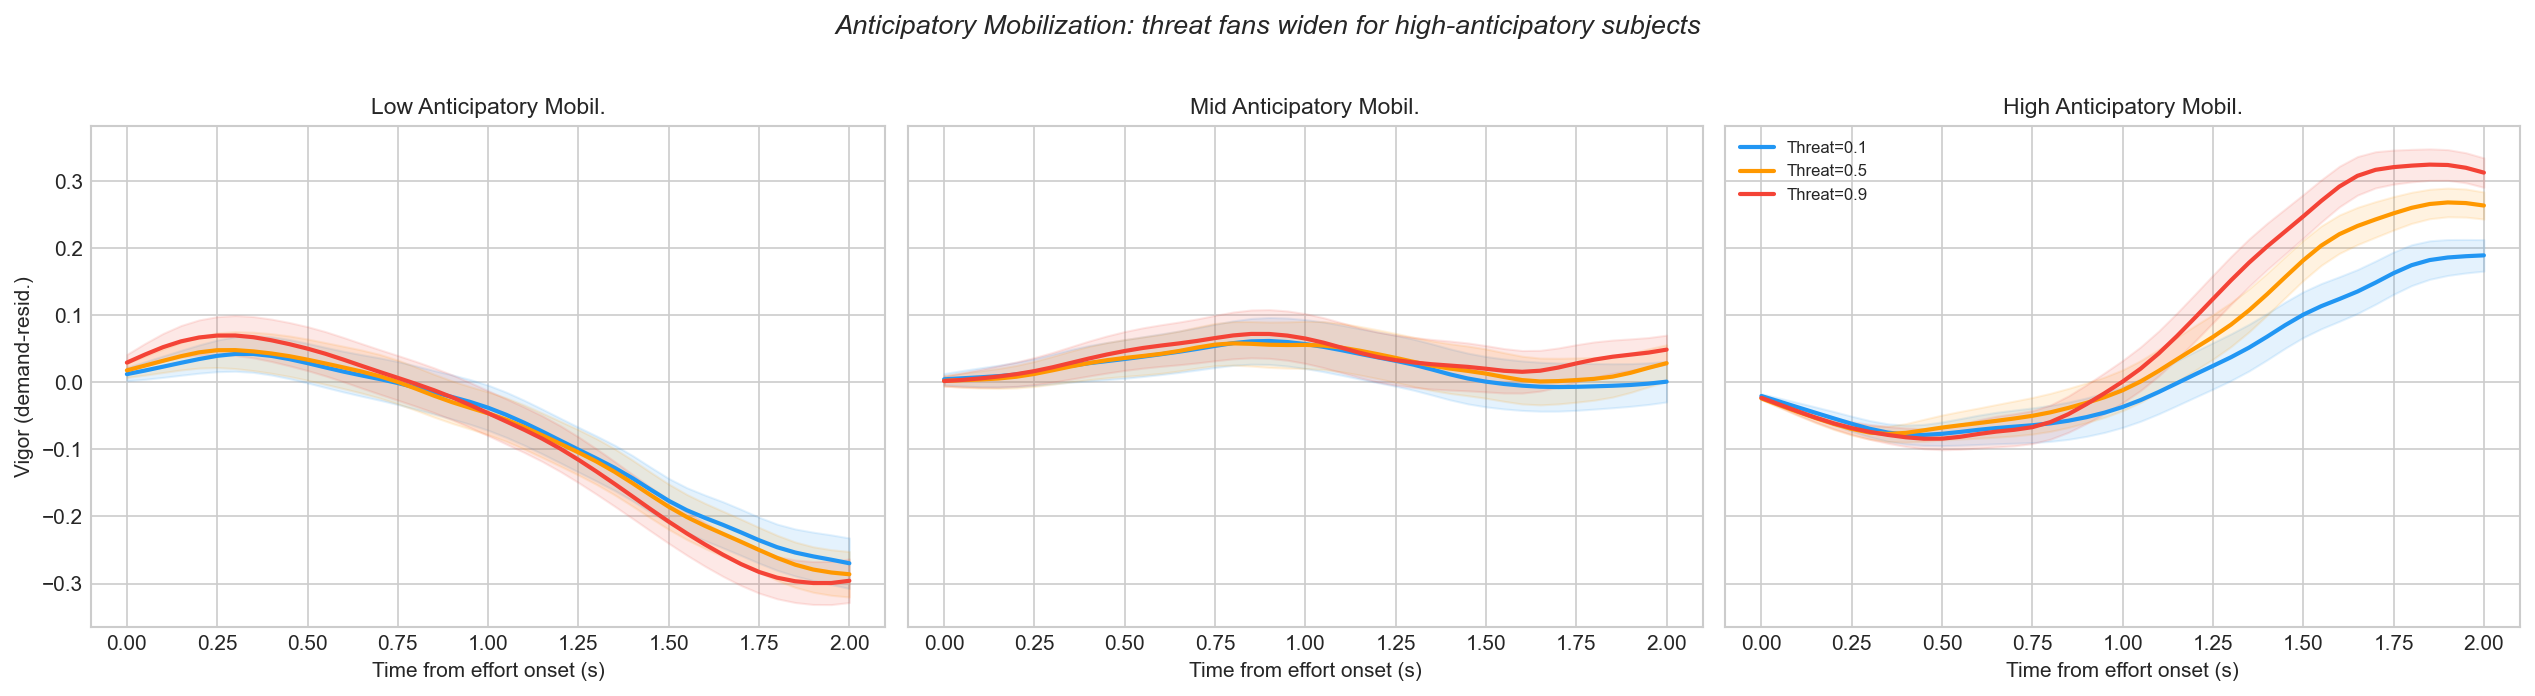

In [27]:
# ── FIGURE: Anticipatory Mobilization — Threat-graded onset ramp ──────────────
# High-anticipatory subjects ramp faster AND show wider threat fans.
# Low-anticipatory subjects show flat onset regardless of threat.
# Each panel = one tertile; colored lines = threat levels.

# Detect threat column name in sv
threat_col = 'threat' if 'threat' in sv_plot.columns else 'threatLevel'
threat_vals = sorted(sv_plot[threat_col].dropna().unique())
print(f'Threat column: {threat_col}, values: {threat_vals}')

# Use 3 canonical levels (low/mid/high)
thr_low, thr_mid, thr_hi = threat_vals[0], threat_vals[len(threat_vals)//2], threat_vals[-1]
threat_palette = {thr_low: '#2196F3', thr_mid: '#FF9800', thr_hi: '#F44336'}

onset_sv = sv_plot[(sv_plot['t'] >= 0) & (sv_plot['t'] <= 2.0)].copy()
onset_sv['t_bin'] = np.round(onset_sv['t'] / DT) * DT

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), dpi=DPI, sharey=True)

for col_idx, tert in enumerate(['Low', 'Mid', 'High']):
    ax = axes[col_idx]
    tert_data = onset_sv[onset_sv['anticipatory_mobilization_tert'] == tert]

    for th in [thr_low, thr_mid, thr_hi]:
        d = tert_data[tert_data[threat_col] == th]
        sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
        gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
        ax.plot(gm['t_bin'], gm['mean'], color=threat_palette[th],
                label=f'Threat={th}', lw=2)
        ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                        alpha=0.12, color=threat_palette[th])

    ax.set_xlabel('Time from effort onset (s)')
    if col_idx == 0:
        ax.set_ylabel('Vigor (demand-resid.)')
    ax.set_title(f'{tert} Anticipatory Mobil.', fontsize=11)
    if col_idx == 2:
        ax.legend(fontsize=8)

fig.suptitle('Anticipatory Mobilization: threat fans widen for high-anticipatory subjects',
             fontsize=13, y=1.02, fontstyle='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_anticipatory_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

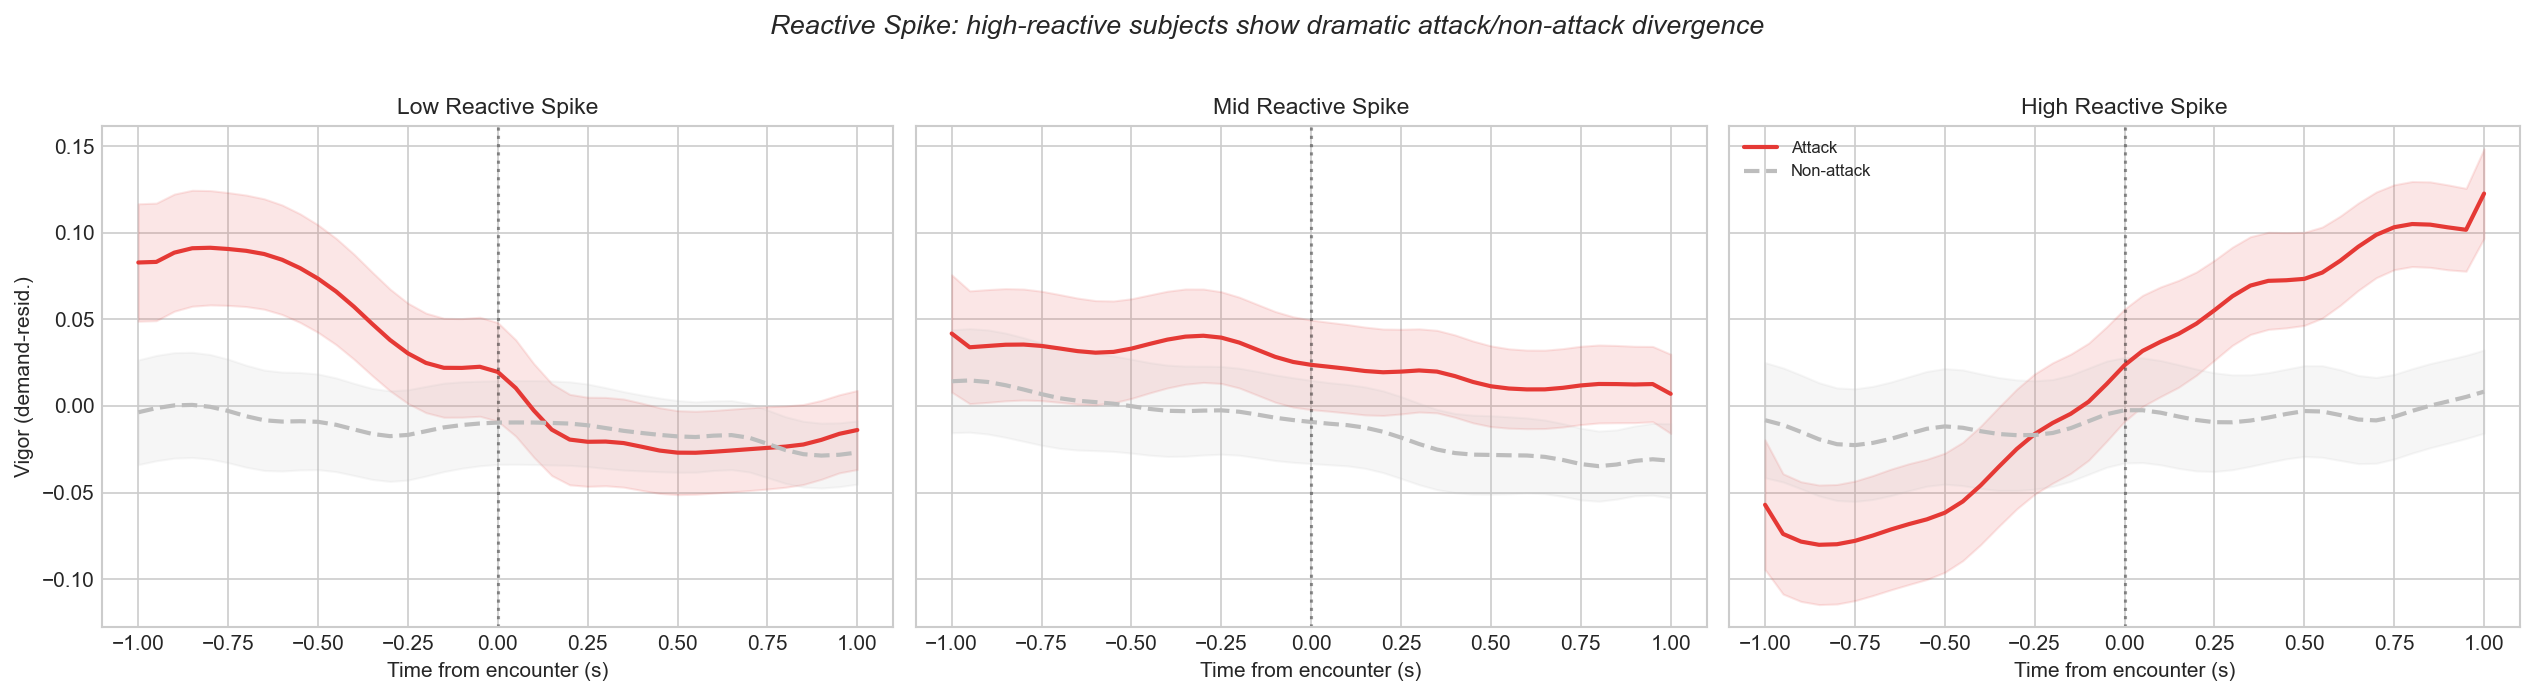

In [28]:
# ── FIGURE: Reactive Spike — Selective encounter response ─────────────────────
# High-reactive subjects show a dramatic attack vs. non-attack divergence;
# low-reactive subjects barely distinguish attack from non-attack.
# Each panel = one tertile; red = attack, gray = non-attack.

enc_all = enc_plot.copy()
enc_all['t_bin'] = np.round(enc_all['t_enc'] / DT) * DT

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), dpi=DPI, sharey=True)

for col_idx, tert in enumerate(['Low', 'Mid', 'High']):
    ax = axes[col_idx]
    tert_data = enc_all[enc_all['reactive_spike_tert'] == tert]

    for atk, color, label, ls in [(1, '#E53935', 'Attack', '-'),
                                   (0, '#BDBDBD', 'Non-attack', '--')]:
        d = tert_data[tert_data['attack'] == atk]
        sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
        gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
        ax.plot(gm['t_bin'], gm['mean'], color=color, ls=ls, label=label, lw=2)
        ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                        alpha=0.12, color=color)

    ax.axvline(0, color='k', ls=':', alpha=0.4)
    ax.set_xlabel('Time from encounter (s)')
    if col_idx == 0:
        ax.set_ylabel('Vigor (demand-resid.)')
    ax.set_title(f'{tert} Reactive Spike', fontsize=11)
    if col_idx == 2:
        ax.legend(fontsize=8)

fig.suptitle('Reactive Spike: high-reactive subjects show dramatic attack/non-attack divergence',
             fontsize=13, y=1.02, fontstyle='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_reactive_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

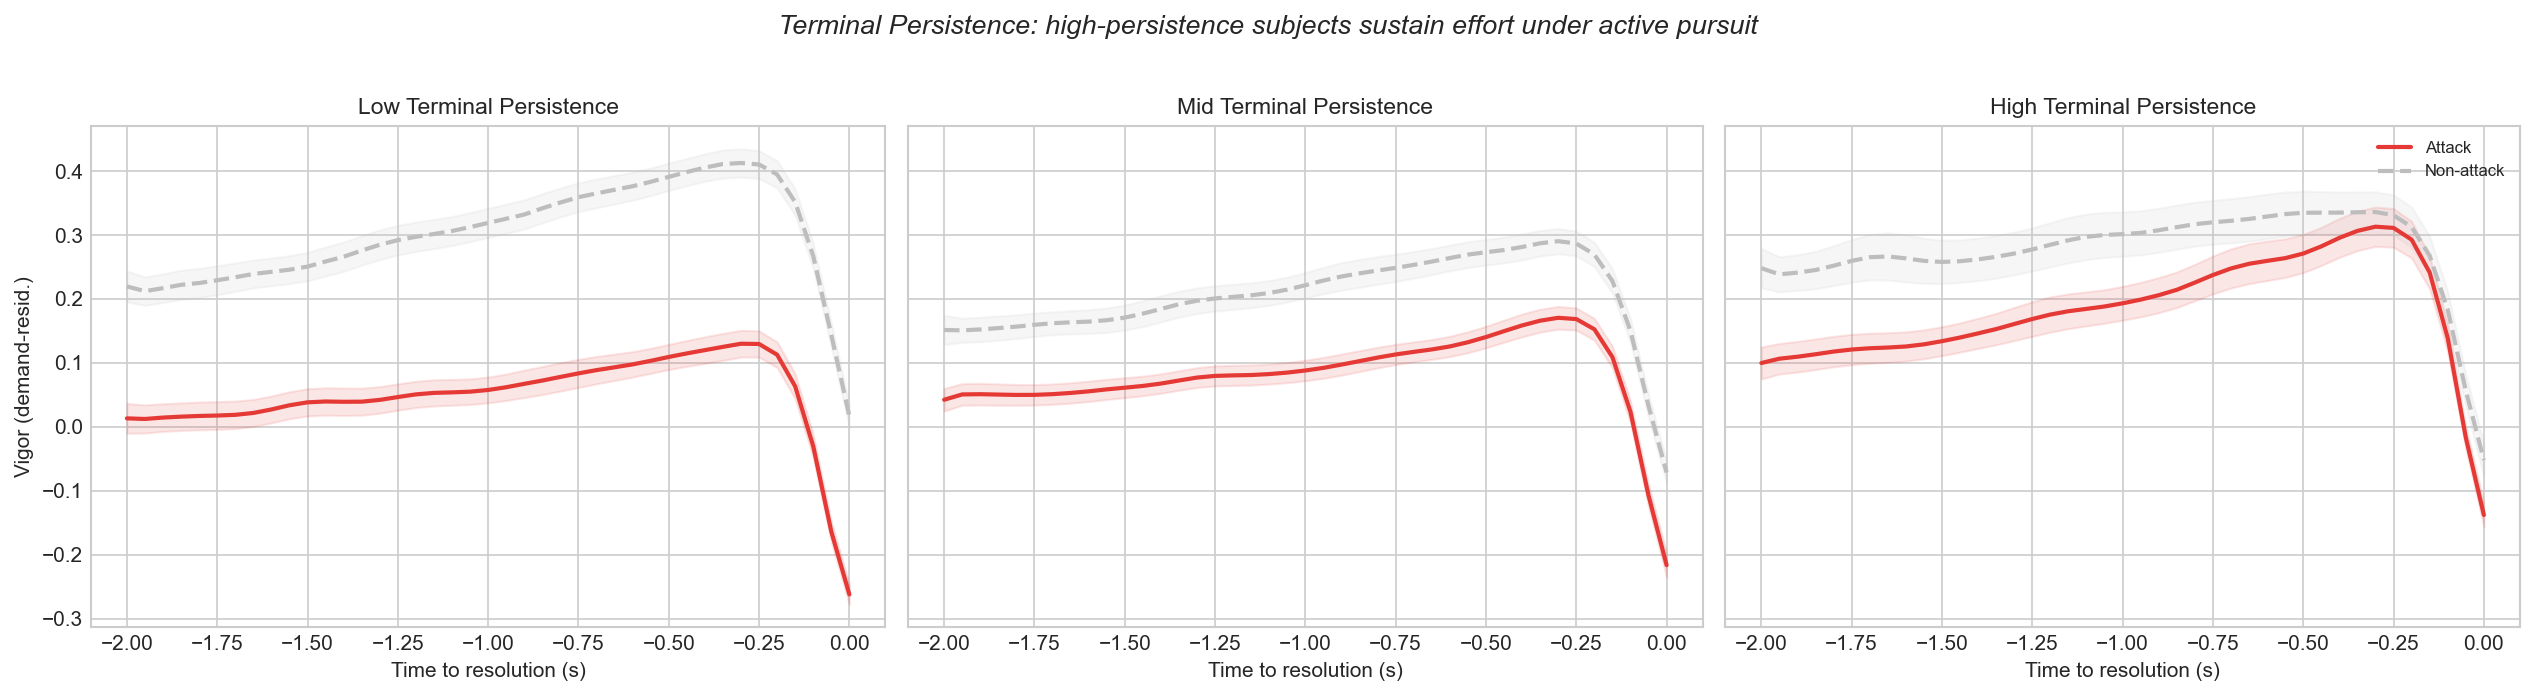

In [29]:
# ── FIGURE: Terminal Persistence — Sustained effort under pursuit ─────────────
# High-persistence subjects maintain or increase effort under attack;
# low-persistence subjects fade or drop off.
# Each panel = one tertile; red = attack, gray = non-attack.

term_all = term_plot.copy()
term_all['t_bin'] = np.round(term_all['t_term'] / DT) * DT

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), dpi=DPI, sharey=True)

for col_idx, tert in enumerate(['Low', 'Mid', 'High']):
    ax = axes[col_idx]
    tert_data = term_all[term_all['terminal_persistence_tert'] == tert]

    for atk, color, label, ls in [(1, '#E53935', 'Attack', '-'),
                                   (0, '#BDBDBD', 'Non-attack', '--')]:
        d = tert_data[tert_data['attack'] == atk]
        sm = d.groupby(['subj', 't_bin'])['vigor_resid'].mean().reset_index()
        gm = sm.groupby('t_bin')['vigor_resid'].agg(['mean', 'sem']).reset_index()
        ax.plot(gm['t_bin'], gm['mean'], color=color, ls=ls, label=label, lw=2)
        ax.fill_between(gm['t_bin'], gm['mean']-gm['sem'], gm['mean']+gm['sem'],
                        alpha=0.12, color=color)

    ax.set_xlabel('Time to resolution (s)')
    if col_idx == 0:
        ax.set_ylabel('Vigor (demand-resid.)')
    ax.set_title(f'{tert} Terminal Persistence', fontsize=11)
    if col_idx == 2:
        ax.legend(fontsize=8)

fig.suptitle('Terminal Persistence: high-persistence subjects sustain effort under active pursuit',
             fontsize=13, y=1.02, fontstyle='italic')
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_terminal_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

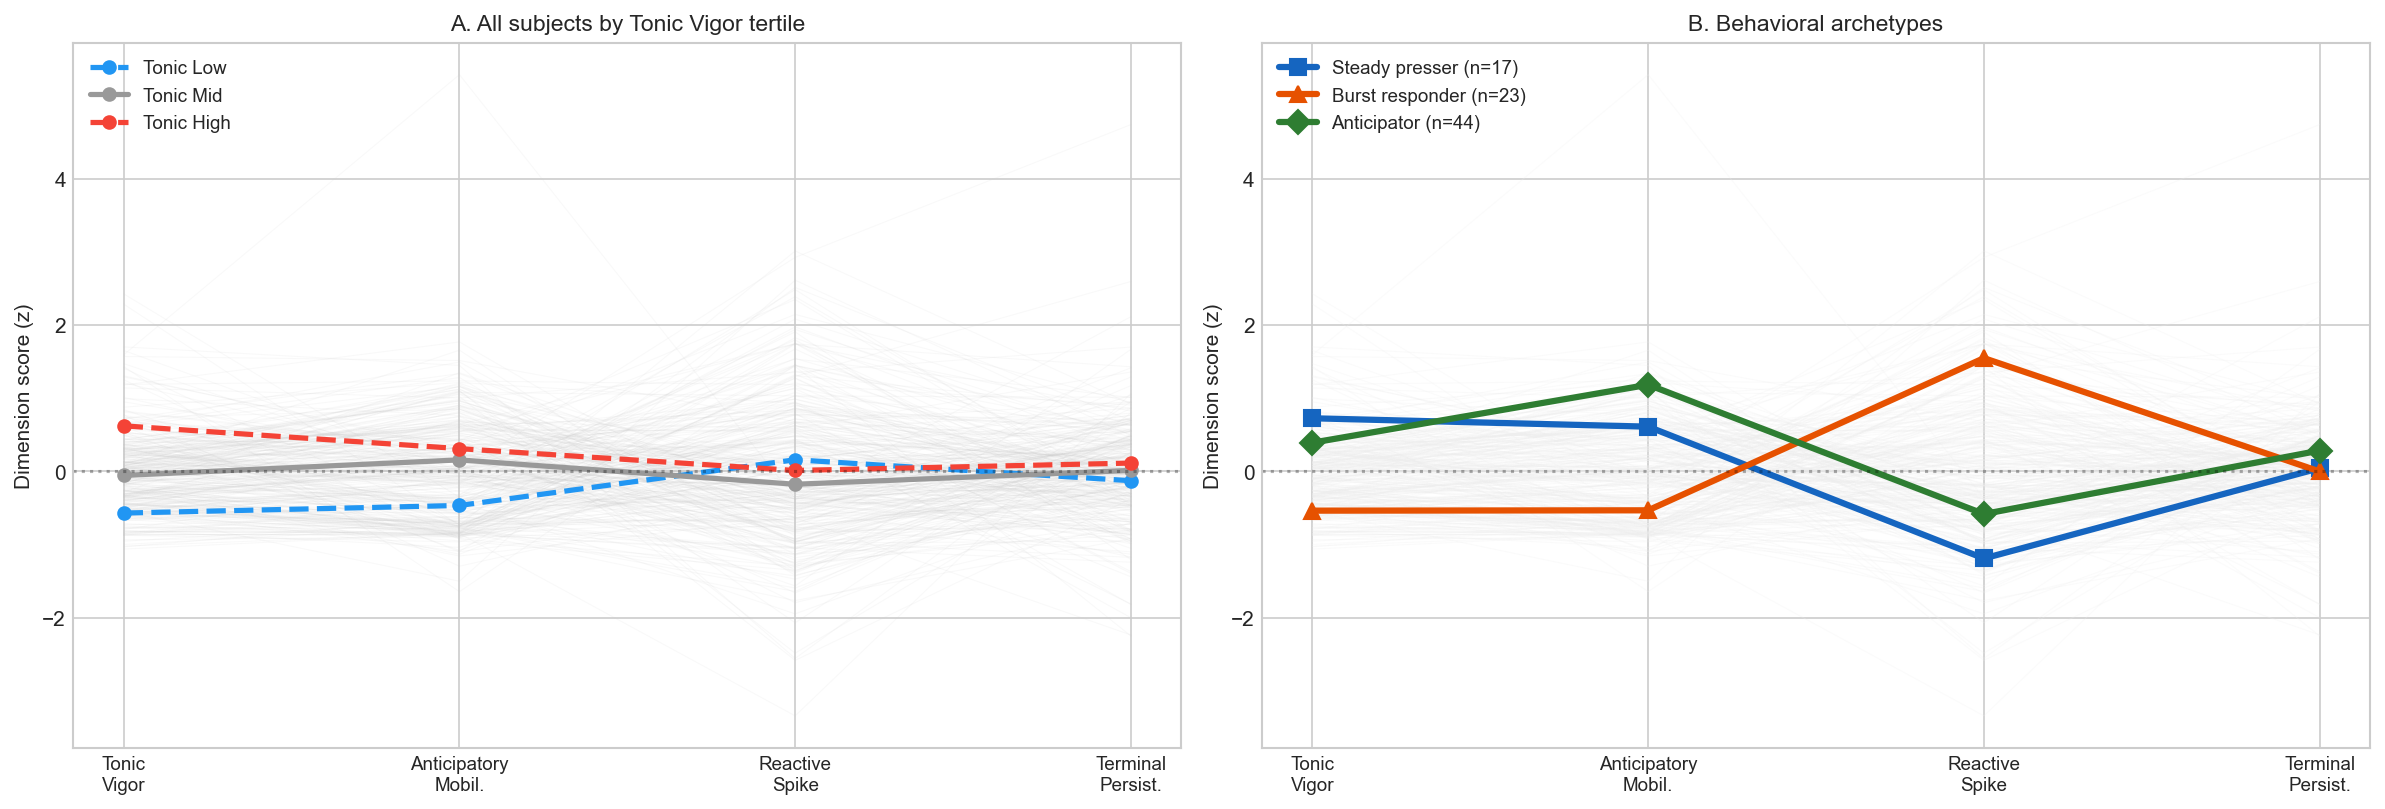

  Steady presser: n=17
    {'tonic_vigor': 0.73, 'anticipatory_mobilization': 0.61, 'reactive_spike': -1.19, 'terminal_persistence': 0.04}
  Burst responder: n=23
    {'tonic_vigor': -0.54, 'anticipatory_mobilization': -0.53, 'reactive_spike': 1.55, 'terminal_persistence': -0.0}
  Anticipator: n=44
    {'tonic_vigor': 0.39, 'anticipatory_mobilization': 1.18, 'reactive_spike': -0.58, 'terminal_persistence': 0.28}


In [30]:
# ── FIGURE: Individual Subject Profiles ──────────────────────────────────────
# Parallel coordinates: each subject as a line across four dimensions.
# Reveals distinct behavioral phenotypes (e.g., steady presser vs. burst responder).

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), dpi=DPI)
dim_short = ['Tonic\nVigor', 'Anticipatory\nMobil.', 'Reactive\nSpike', 'Terminal\nPersist.']

# Panel A: All subjects, highlighted by tonic vigor tertile
ax = axes[0]
profile = subj_table[dims].dropna()

for _, row in profile.iterrows():
    ax.plot(range(4), row[dims].values, color='#CCCCCC', alpha=0.12, lw=0.5)

for tert, color, ls in [('Low', '#2196F3', '--'), ('Mid', '#999999', '-'),
                         ('High', '#F44336', '--')]:
    mask = subj_table['tonic_vigor_tert'] == tert
    m = subj_table.loc[mask, dims].mean()
    ax.plot(range(4), m.values, color=color, lw=2.5, ls=ls,
            label=f'Tonic {tert}', marker='o', ms=6)

ax.set_xticks(range(4))
ax.set_xticklabels(dim_short, fontsize=9)
ax.set_ylabel('Dimension score (z)')
ax.set_title('A. All subjects by Tonic Vigor tertile', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='k', ls=':', alpha=0.3)

# Panel B: Behavioral archetypes
ax = axes[1]

# Define archetypes by extreme dimension combinations
steady = profile[
    (profile['tonic_vigor'] > profile['tonic_vigor'].quantile(0.80)) &
    (profile['reactive_spike'] < profile['reactive_spike'].quantile(0.30))]
burst = profile[
    (profile['tonic_vigor'] < profile['tonic_vigor'].quantile(0.30)) &
    (profile['reactive_spike'] > profile['reactive_spike'].quantile(0.80))]
prepared = profile[
    profile['anticipatory_mobilization'] > profile['anticipatory_mobilization'].quantile(0.85)]

for _, row in profile.iterrows():
    ax.plot(range(4), row[dims].values, color='#EEEEEE', alpha=0.25, lw=0.5)

archetypes = [
    (steady,   '#1565C0', 'Steady presser',  's'),
    (burst,    '#E65100', 'Burst responder', '^'),
    (prepared, '#2E7D32', 'Anticipator',     'D'),
]
for grp, color, label, marker in archetypes:
    if len(grp) > 3:
        ax.plot(range(4), grp[dims].mean().values, color=color, lw=3,
                label=f'{label} (n={len(grp)})', marker=marker, ms=8)

ax.set_xticks(range(4))
ax.set_xticklabels(dim_short, fontsize=9)
ax.set_ylabel('Dimension score (z)')
ax.set_title('B. Behavioral archetypes', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(0, color='k', ls=':', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb2_subject_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

for grp, _, label, _ in archetypes:
    if len(grp) > 3:
        print(f'  {label}: n={len(grp)}')
        print(f'    {grp[dims].mean().round(2).to_dict()}')

## Section 5: Save

In [31]:
# ── SAVE ──────────────────────────────────────────────────────────────────────

outpath = DATA_PROC / 'subject_vigor_table.csv'
subj_table.to_csv(outpath, index=False)
print(f'Saved {outpath}: {subj_table.shape}')

# Summary of output columns
print(f'\nColumns ({len(subj_table.columns)}):')
for col in subj_table.columns:
    n_valid = subj_table[col].notna().sum()
    print(f'  {col:30s}: {n_valid}/{len(subj_table)} valid')

Saved ../../data/processed/subject_vigor_table.csv: (292, 33)

Columns (33):
  subj                          : 292/292 valid
  onset_slope_mean              : 292/292 valid
  onset_mean_mean               : 292/292 valid
  onset_threat_mod              : 292/292 valid
  enc_baseline                  : 292/292 valid
  enc_post_effect               : 292/292 valid
  enc_attack_effect             : 292/292 valid
  enc_selective_spike           : 292/292 valid
  term_baseline                 : 292/292 valid
  term_slope_base               : 292/292 valid
  term_attack_boost             : 292/292 valid
  term_attack_slope             : 292/292 valid
  onset_mean_mean_z             : 292/292 valid
  enc_baseline_z                : 292/292 valid
  term_baseline_z               : 292/292 valid
  tonic_vigor                   : 292/292 valid
  onset_slope_mean_z            : 292/292 valid
  onset_threat_mod_z            : 292/292 valid
  anticipatory_mobilization     : 292/292 valid
  reactive_

## Summary

**11 raw features** extracted per subject (3 onset, 4 encounter, 4 terminal).

**3 a priori vigor dimensions:**
1. **Tonic Vigor** = z-mean of (onset_mean_mean, enc_baseline, term_baseline)
2. **Threat Reactivity** = z-mean of (onset_threat_mod, enc_selective_spike, term_attack_boost)
3. **Phasic Burst** = enc_selective_spike residualized on tonic_vigor

**Choice parameters** (z, κ, β) merged from hierarchical Bayesian model fits.

Output: `subject_vigor_table.csv` (292 rows) ready for NB3 (choice-vigor mapping) and NB4 (clinical prediction).